### Distribution Before the Values Goes Into The Model After Normalization

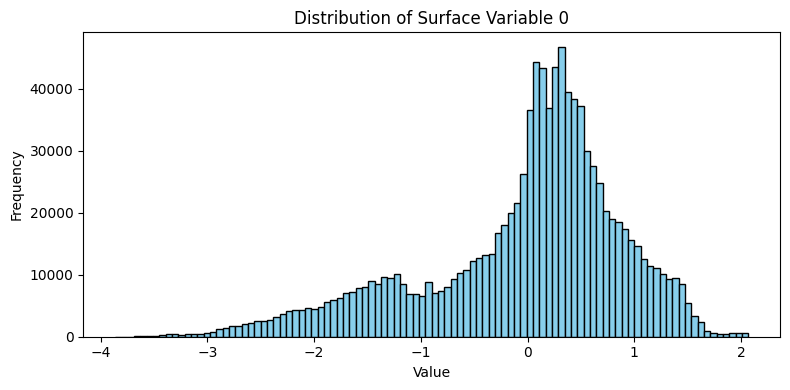

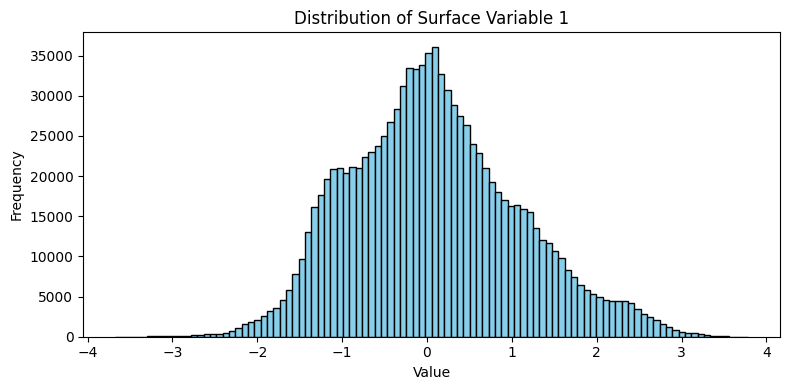

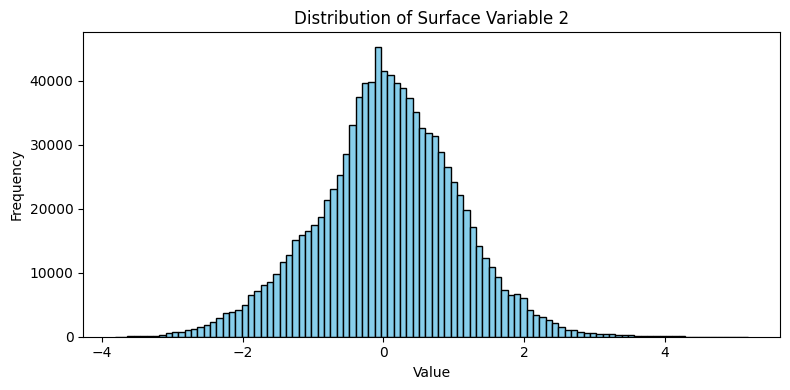

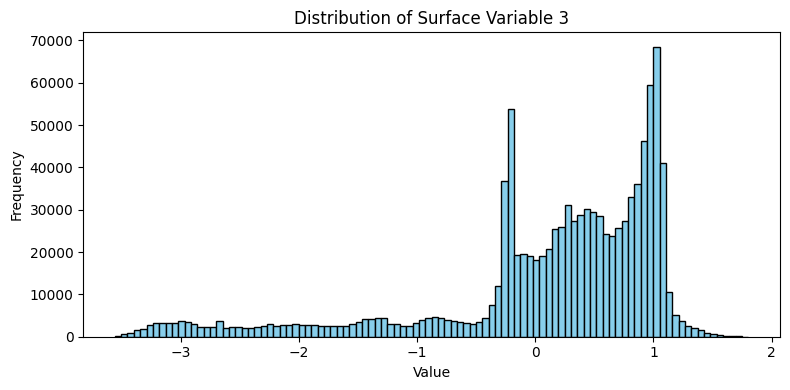

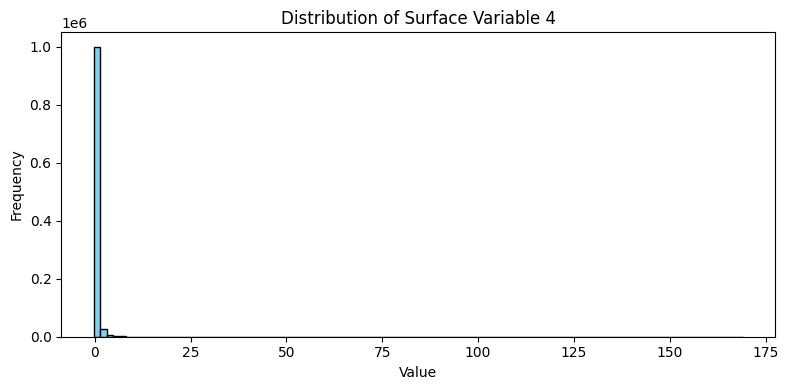

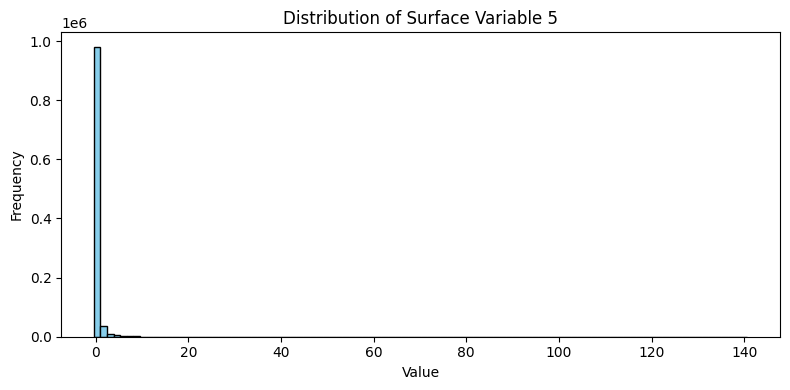

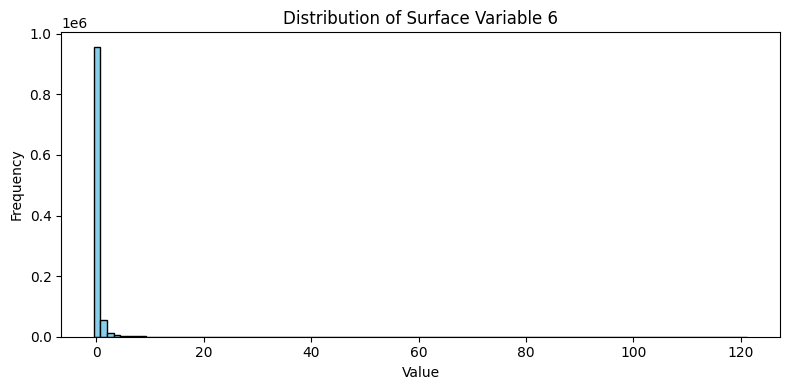

In [1]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt
import os

# Load the tensor
input_surface = torch.load("/l/users/fahad.khan/akhtar/Pangu/pangu-pytorch/data/stats/input_surface.pt")  # shape: [1, 7, 721, 1440]

# Remove batch dimension
input_surface = input_surface.squeeze(0)  # shape: [7, 721, 1440]

# Optional: Create output directory for saving plots
plot_output_dir = "/l/users/fahad.khan/akhtar/Pangu/pangu-pytorch/data/stats/surface_distributions"
os.makedirs(plot_output_dir, exist_ok=True)

# Plot and display distribution for each variable
for i in range(7):
    data = input_surface[i].cpu().numpy().flatten()

    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=100, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of Surface Variable {i}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.tight_layout()

    # Save and show
    plot_path = os.path.join(plot_output_dir, f"surface_variable_{i}_hist.png")
    plt.savefig(plot_path)
    plt.show()  # Shows the plot inline

Just normalization does not help. We have to use a log transformation.

### Distribution Before the Values For 2019 After Normalization

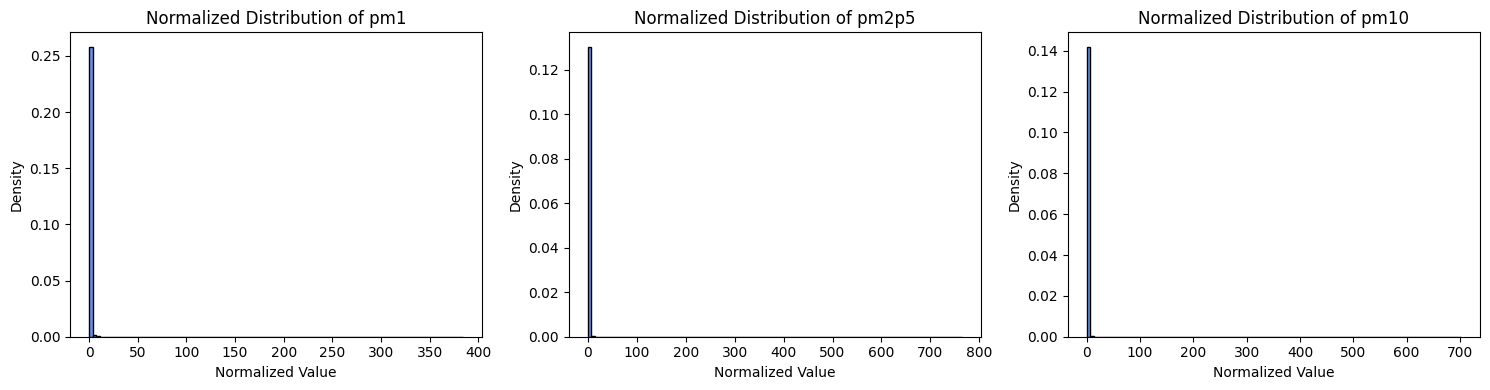

In [2]:
import xarray as xr
import numpy as np
import glob
import matplotlib.pyplot as plt

# File pattern (2019 data)
input_pattern = "/l/users/fahad.khan/akhtar/Pangu/data/pangu_data/surface/surface_2019*.nc"

# PM variables and corresponding stats (from your high-precision output)
pm_stats = {
    'pm1':   {'mean': 4.7033090000e-09, 'std': 1.7588029000e-08},
    'pm2p5': {'mean': 1.0949457000e-08, 'std': 2.7642354000e-08},
    'pm10':  {'mean': 1.7928459000e-08, 'std': 4.1681563000e-08},
}

# Load all 2019 surface files
ds = xr.open_mfdataset(sorted(glob.glob(input_pattern)), combine='by_coords')

# Plot setup
plt.figure(figsize=(15, 4))
for i, var in enumerate(pm_stats.keys()):
    data = ds[var].values  # [time, lat, lon]
    flat = data.reshape(-1)
    flat = flat[~np.isnan(flat)]  # remove NaNs

    # Normalize
    mean = pm_stats[var]['mean']
    std = pm_stats[var]['std']
    normalized = (flat - mean) / std

    # Plot histogram
    plt.subplot(1, 3, i+1)
    plt.hist(normalized, bins=100, color='cornflowerblue', edgecolor='black', density=True)
    plt.title(f"Normalized Distribution of {var}")
    plt.xlabel("Normalized Value")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [3]:
ds

<xarray.Dataset> Size: 33GB
Dimensions:    (time: 730, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2019-01-01 ... 2019-12-31T12:00:00
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
Data variables:
    pm1        (time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    pm2p5      (time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    pm10       (time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    u10        (time, latitude, longitude) float64 6GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    v10        (time, latitude, longitude) float64 6GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    t2m        (time, latitude, longitude) float64 6GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    msl        (time, latitude, longitude) float64 6GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Sat May 31 17:49:33 2025: cdo merge /media/akhtarmunir/Extr...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

Skewness of pm1: 44.3324
Skewness of pm2p5: 64.7987
Skewness of pm10: 54.1115


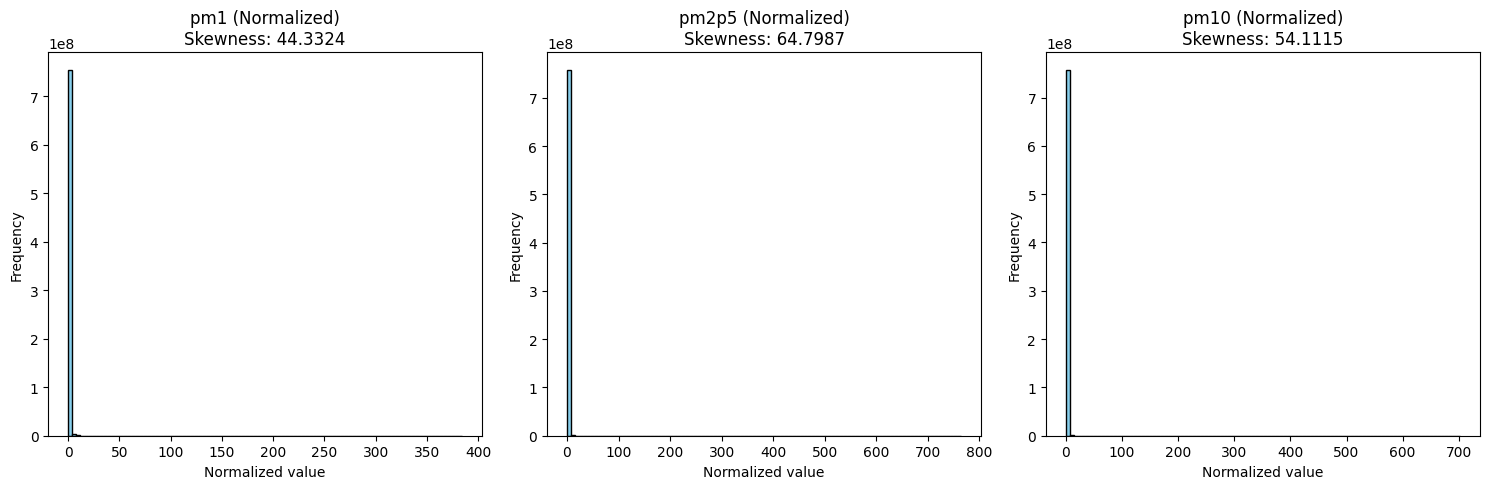

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

pm_vars = ['pm1', 'pm2p5', 'pm10']

plt.figure(figsize=(15, 5))

for i, var in enumerate(pm_vars):
    # Extract data and flatten
    data = ds[var].values
    flat = data.reshape(-1)
    flat = flat[~np.isnan(flat)]
    
    # Normalize
    mean_val = np.mean(flat)
    std_val = np.std(flat)
    normalized = (flat - mean_val) / std_val
    
    # Calculate skewness
    skewness = skew(normalized)
    print(f"Skewness of {var}: {skewness:.4f}")
    
    # Plot histogram with skewness in title
    plt.subplot(1, 3, i+1)
    plt.hist(normalized, bins=100, color='skyblue', edgecolor='black')
    plt.title(f"{var} (Normalized)\nSkewness: {skewness:.4f}")
    plt.xlabel("Normalized value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Interpretation of Skewness Values

* Skewness is a measure of the asymmetry of the data distribution. Typically, skewness values greater than 1 or less than -1 indicate a highly skewed distribution. 

* In our analysis, the PM concentration variables (pm1, pm2p5, and pm10) exhibited extremely high skewness values, all exceeding 40. This level of skewness is exceptionally high and indicates that the data distribution is heavily right-skewed.

* In practical terms, this means that most data points are concentrated near the lower end of the value range—likely close to zero or other small values—while a small number of observations have very large values. These large values create a long, heavy tail on the right side of the distribution.

Reasons for High Skewness in PM Data

•	Non-negativity and Background Levels: PM concentrations are inherently non-negative and often hover near low background levels in many locations and times.

•	Pollution Spikes: Intermittent pollution events or spikes can generate a small number of very high PM readings relative to the baseline.

•	Natural Phenomena and Measurement Variability: Environmental factors such as dust storms, wildfires, or measurement errors may introduce extreme values or outliers.

•	Normalization Without Transformation: If the data normalization uses only mean and standard deviation scaling on raw PM values without applying a log-transform or similar adjustment, the skewness of the distribution remains pronounced.


## Distribution After Log Scaling and Normalizing

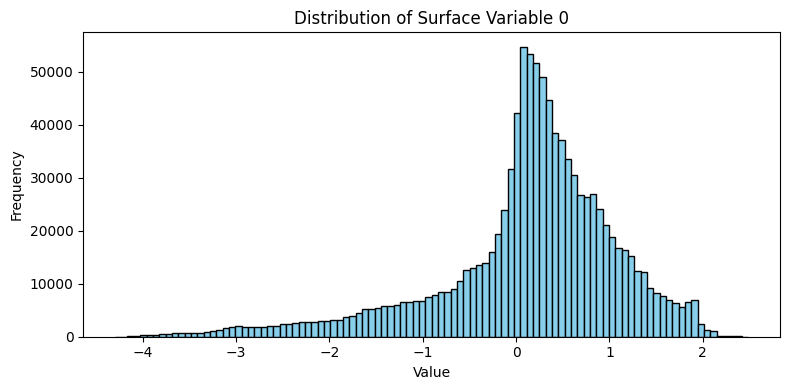

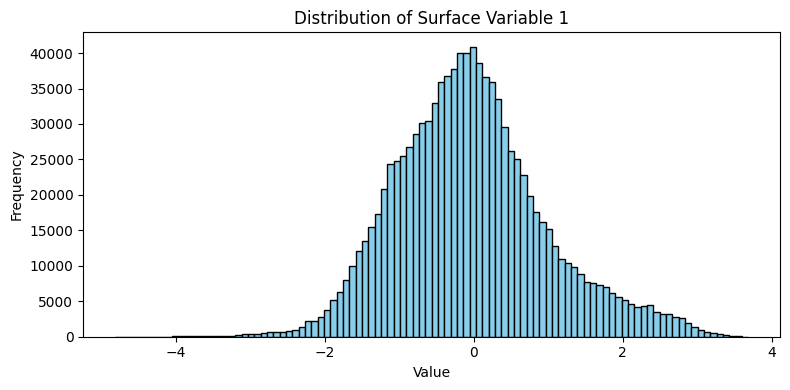

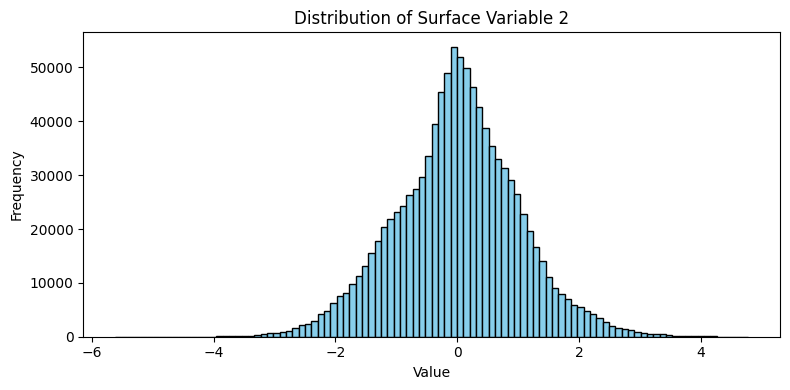

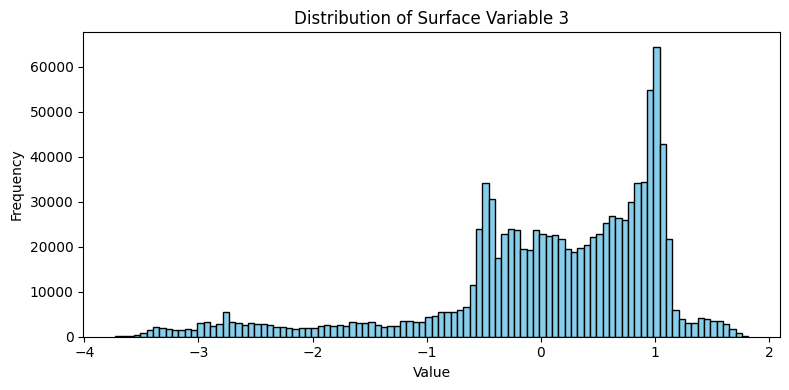

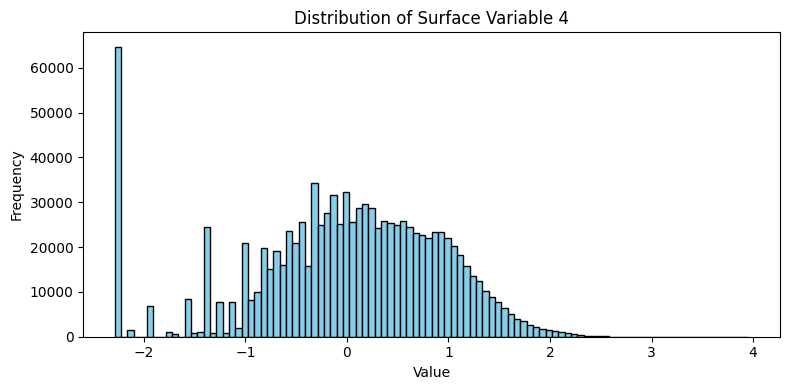

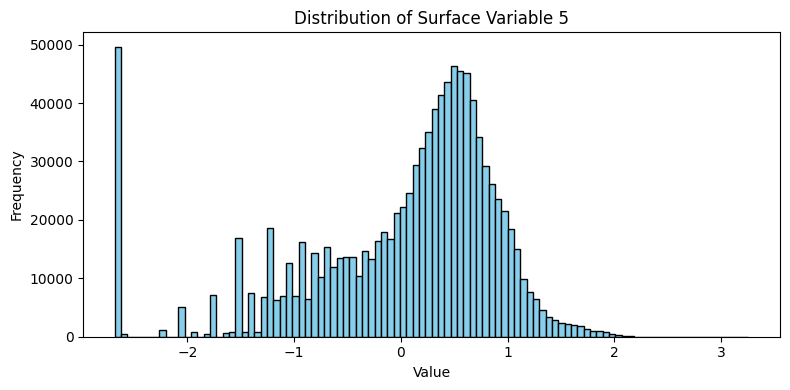

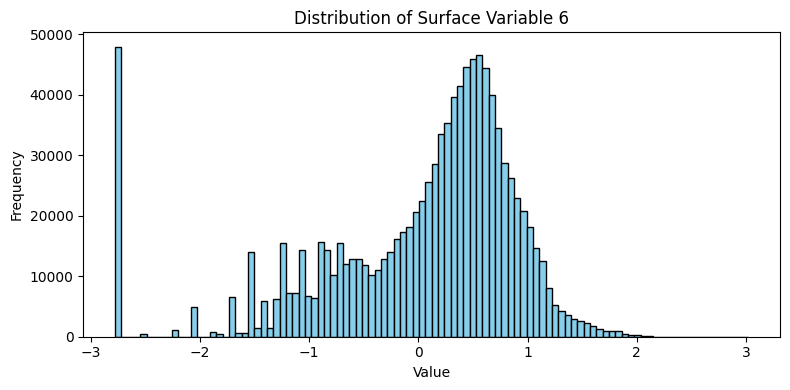

In [5]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt
import os

# Load the tensor
input_surface = torch.load("/l/users/fahad.khan/akhtar/Pangu/pangu-pytorch/data/stats/After_log_transform/surface.pt")  # shape: [1, 7, 721, 1440]

# Remove batch dimension
input_surface = input_surface.squeeze(0)  # shape: [7, 721, 1440]

# Optional: Create output directory for saving plots
plot_output_dir = "/l/users/fahad.khan/akhtar/Pangu/pangu-pytorch/data/stats/After_log_transform"
os.makedirs(plot_output_dir, exist_ok=True)

# Plot and display distribution for each variable
for i in range(7):
    data = input_surface[i].cpu().numpy().flatten()

    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=100, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of Surface Variable {i}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.tight_layout()

    # Save and show
    plot_path = os.path.join(plot_output_dir, f"surface_variable_{i}_hist.png")
    plt.savefig(plot_path)
    plt.show()  # Shows the plot inline